In [ ]:
!pip install torch torchvision scikit-learn pandas matplotlib pillow -q
import os
import sys
import time
import json
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 10
print("Semua library berhasil di-import.")

Semua library berhasil di-import.


In [ ]:
from google.colab import files
import zipfile, shutil, os

uploaded = files.upload()

ZIP_NAME = list(uploaded.keys())[0]
print(f"File terupload: {ZIP_NAME}")

Saving hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0.zip to hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0 (1).zip
File terupload: hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0 (1).zip


In [ ]:
DATA_DIR = "data"
RAW_IMAGE_DIR = os.path.join(DATA_DIR, "images")
LABELS_CSV = os.path.join(DATA_DIR, "Labels.csv")
os.makedirs(RAW_IMAGE_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_NAME, 'r') as z:
    print("Isi zip:", z.namelist()[:10], "...")
    z.extractall("data_raw")

moved = 0
for root, _, files_list in os.walk("data_raw"):
    for fname in files_list:
        src = os.path.join(root, fname)
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            shutil.copy2(src, os.path.join(RAW_IMAGE_DIR, fname))
            moved += 1
        elif fname.lower() == "labels.csv":
            shutil.copy2(src, LABELS_CSV)

print(f"{moved} gambar dipindahkan ke {RAW_IMAGE_DIR}")
print(f"Labels.csv ditemukan: {os.path.exists(LABELS_CSV)}")

Isi zip: ['hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Images/0_0.jpg', 'hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Images/100_0.jpg', 'hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Images/100_1.jpg', 'hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Images/100_2.jpg', 'hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Images/100_3.jpg', 'hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Images/100_4.jpg', 'hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Images/100_5.jpg', 'hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Images/100_

In [ ]:
import pandas as pd

df_check = pd.read_csv(LABELS_CSV)
n_images = len([f for f in os.listdir(RAW_IMAGE_DIR) if f.lower().endswith((".jpg",".jpeg",".png"))])

print(f"Labels.csv    -> {len(df_check)} baris")
print(f"Gambar di disk -> {n_images} file")
print(f"Pasien unik   -> {df_check['Patient'].nunique()}")
print(f"Kolom tersedia: {list(df_check.columns)}")
print(f"\nDistribusi label:\n{df_check['Label'].value_counts()}")
print(f"\n3 baris pertama:\n{df_check.head(3)}")

Labels.csv    -> 747 baris
Gambar di disk -> 747 file
Pasien unik   -> 288
Kolom tersedia: ['Image Name', 'Patient', 'Label', 'Quality Score', 'Unnamed: 4']

Distribusi label:
Label
GON+    548
GON-    199
Name: count, dtype: int64

3 baris pertama:
  Image Name  Patient Label  Quality Score  Unnamed: 4
0    0_0.jpg        0  GON+           6.18         NaN
1    1_0.jpg        1  GON+           5.31         NaN
2    1_1.jpg        1  GON+           4.37         NaN


CONFIG

In [ ]:
SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

QUALITY_BINS = {
    "low": (1, 4),
    "medium": (5, 7),
    "high": (8, 10),
}

IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

BATCH_SIZE = 16
NUM_EPOCHS = 40
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 7
LR_SCHEDULER_PATIENCE = 3
LR_SCHEDULER_FACTOR = 0.5
DROPOUT_RATE = 0.4
GRADIENT_CLIP_NORM = 1.0

LABEL_MAP = {"GON+": 1, "GON-": 0}
POSITIVE_CLASS_NAME = "GON+"
NEGATIVE_CLASS_NAME = "GON-"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang dipakai: {DEVICE}")

OUTPUT_DIR = "outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
for d in [FIGURES_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

MODEL_BASELINE = "baseline_cnn"
MODEL_QUALITY_AWARE = "quality_aware_cnn"
MODEL_TRANSFER = "transfer_resnet18"

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
print("Konfigurasi selesai.")

Device yang dipakai: cuda
Konfigurasi selesai.


PATIENT-LEVEL SPLIT

In [ ]:
def load_labels(path=LABELS_CSV):
  df = pd.read_csv(path)
  df.columns = [c.strip() for c in df.columns]

  required_cols = {"Image Name", "Patient", "Label", "Quality Score"}
  missing = required_cols - set(df.columns)
  if missing:
      raise ValueError(f"Kolom berikut tidak ditemukan: {missing}. Kolom tersedia: {list(df.columns)}")

  df["Label"] = df["Label"].astype(str).str.strip()
  df["label_binary"] = df["Label"].map(LABEL_MAP)

  if df["label_binary"].isna().any():
      unmapped = df.loc[df["label_binary"].isna(), "Label"].unique()
      raise ValueError(f"Label tidak dikenali: {unmapped}")

  return df


def get_patient_dominant_label(df):
    patient_label_counts = df.groupby("Patient")["label_binary"].nunique()
    inconsistent = patient_label_counts[patient_label_counts > 1].index.tolist()
    if inconsistent:
        print(f"[INFO] {len(inconsistent)} pasien punya label GON+ dan GON- berbeda antar gambar "
              f"(misal mata kiri vs kanan). Label representatif diambil dari modus.")

    patient_label = (
        df.groupby("Patient")["label_binary"]
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
        .rename(columns={"label_binary": "patient_label"})
    )
    return patient_label


def split_patients(patient_label_df, seed=SEED):
    train_p, temp_p = train_test_split(
        patient_label_df, train_size=TRAIN_RATIO,
        stratify=patient_label_df["patient_label"], random_state=seed
    )
    val_prop = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    val_p, test_p = train_test_split(
        temp_p, train_size=val_prop,
        stratify=temp_p["patient_label"], random_state=seed
    )
    train_p = train_p.assign(split="train")
    val_p = val_p.assign(split="val")
    test_p = test_p.assign(split="test")
    return pd.concat([train_p, val_p, test_p], ignore_index=True)


def assign_split_to_images(df, patient_split_df):
    merged = df.merge(patient_split_df[["Patient", "split"]], on="Patient", how="left")
    if merged["split"].isna().any():
        raise RuntimeError("Ada gambar tanpa pasangan pasien di hasil split.")
    return merged


def assert_no_leakage(df):
    """WAJIB: pastikan tidak ada pasien yang bocor antar split."""
    patient_splits = df.groupby("Patient")["split"].nunique()
    leaking = patient_splits[patient_splits > 1]
    if len(leaking) > 0:
        raise AssertionError(f"DATA LEAKAGE TERDETEKSI! Pasien bocor: {leaking.index.tolist()}")
    print("[OK] Sanity check lolos: tidak ada pasien yang bocor antar split.")


def summarize_split(df):
    print("\n=== Ringkasan Patient-Level Split ===")
    summary = df.groupby("split").agg(
        n_images=("Image Name", "count"),
        n_patients=("Patient", "nunique"),
        n_positive=("label_binary", "sum"),
    )
    summary["n_negative"] = summary["n_images"] - summary["n_positive"]
    summary["pct_positive"] = (summary["n_positive"] / summary["n_images"] * 100).round(1)
    print(summary)
    print(f"\nTotal gambar: {len(df)} | Total pasien unik: {df['Patient'].nunique()}")


# Jalankan
df_labels = load_labels()
patient_label_df = get_patient_dominant_label(df_labels)
patient_split_df = split_patients(patient_label_df)
split_df = assign_split_to_images(df_labels, patient_split_df)

assert_no_leakage(split_df)
summarize_split(split_df)

split_df.to_csv(os.path.join(DATA_DIR, "splits.csv"), index=False)
print("\nHasil split disimpan ke data/splits.csv")


[OK] Sanity check lolos: tidak ada pasien yang bocor antar split.

=== Ringkasan Patient-Level Split ===
       n_images  n_patients  n_positive  n_negative  pct_positive
split                                                            
test        121          44          92          29          76.0
train       502         201         363         139          72.3
val         124          43          93          31          75.0

Total gambar: 747 | Total pasien unik: 288

Hasil split disimpan ke data/splits.csv


EDA

Total gambar       : 747
Total pasien unik  : 288
Distribusi kelas   :
Label
GON+    548
GON-    199
Name: count, dtype: int64

Statistik Quality Score:
count    747.000000
mean       5.904311
std        1.007189
min        2.040000
25%        5.365000
50%        6.180000
75%        6.630000
max        7.690000
Name: Quality Score, dtype: float64

Distribusi bin kualitas:
quality_bin
medium     557
unknown    144
low         46
Name: count, dtype: int64



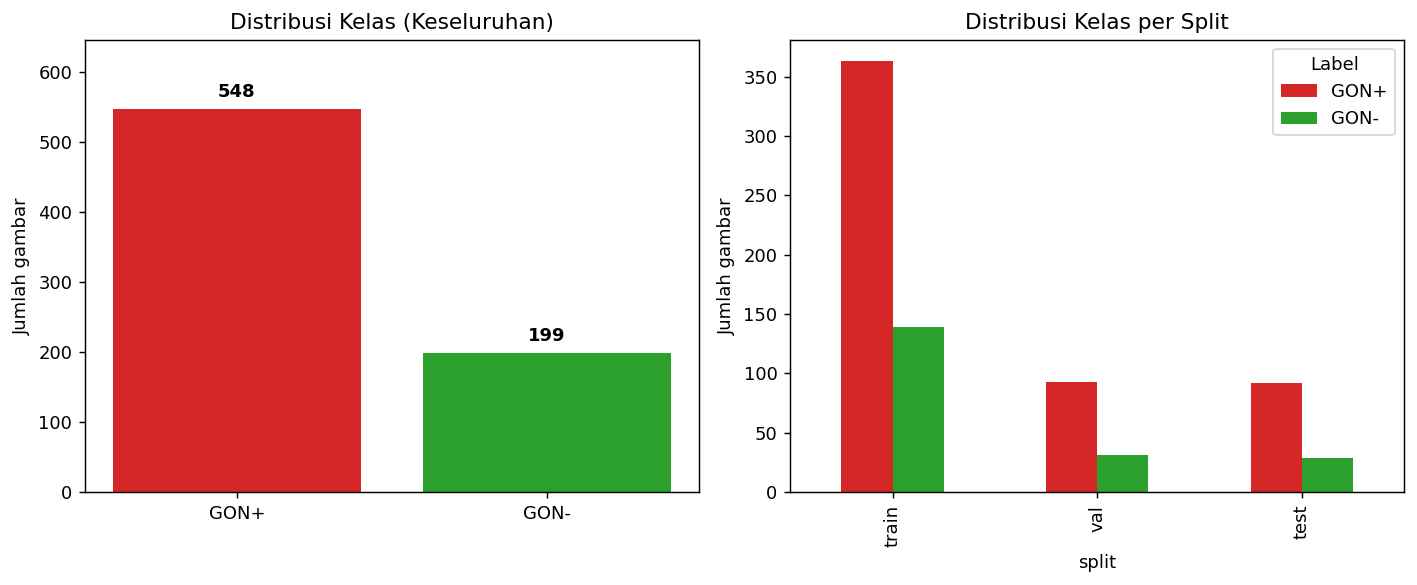

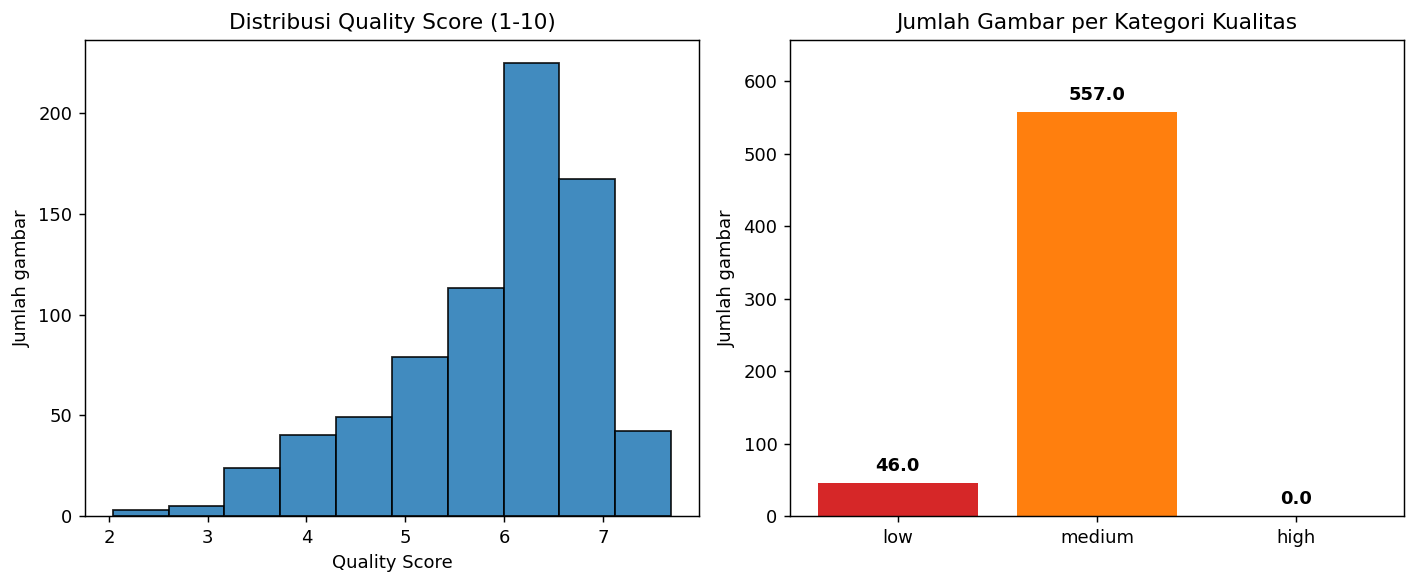

/tmp/ipykernel_5381/68728202.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME])


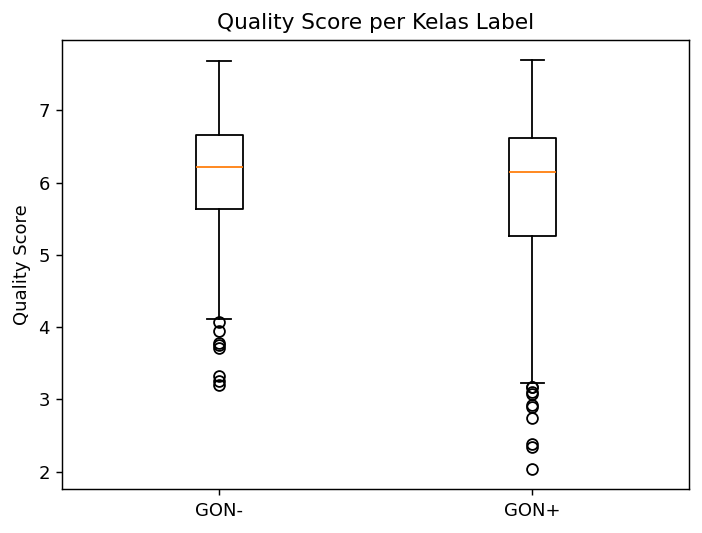

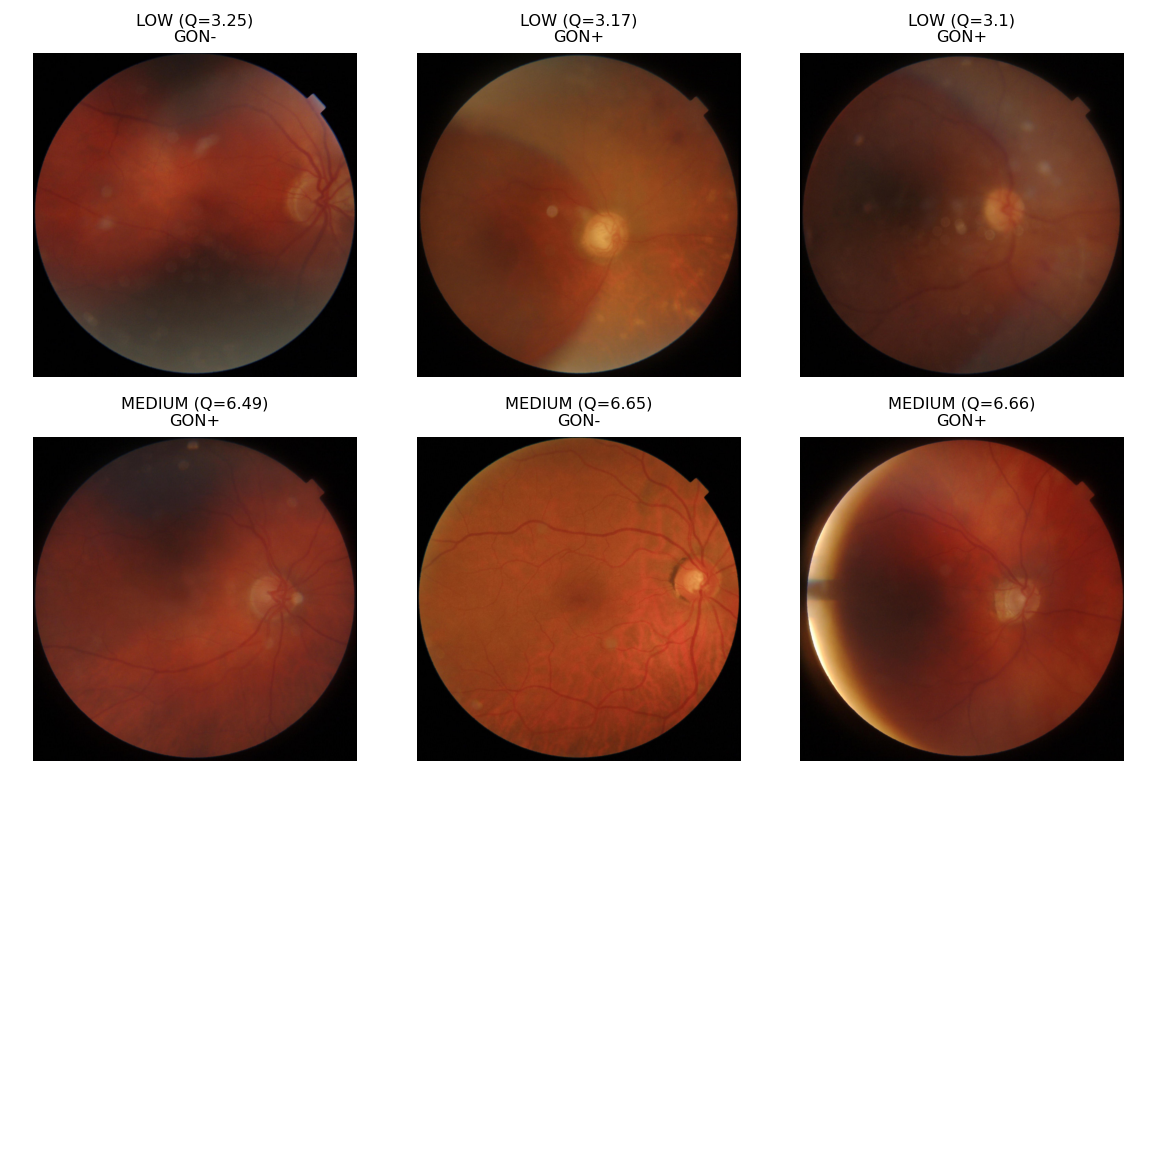


=== Laporan Pengecekan Preprocessing ===
Ukuran gambar unik (sample): {(1893, 1893), (1879, 1879), (1888, 1888), (1911, 1911), (1920, 1920), (1898, 1898), (1889, 1889), (1880, 1880), (1875, 1875), (1922, 1922), (1894, 1894), (1881, 1881), (1908, 1908), (1899, 1899), (1890, 1890), (1886, 1886), (1895, 1895), (1927, 1927), (1905, 1905), (1914, 1914), (1960, 1960), (1891, 1891), (1909, 1909), (1928, 1928), (1910, 1910), (1919, 1919), (1937, 1937), (1878, 1878), (1901, 1901), (1887, 1887)}
Mode warna unik (sample): {'RGB'}
Jumlah file korup/missing: 0


In [ ]:
def assign_quality_bin(score):
    for bin_name, (lo, hi) in QUALITY_BINS.items():
        if lo <= score <= hi:
            return bin_name
    return "unknown"

split_df["quality_bin"] = split_df["Quality Score"].apply(assign_quality_bin)

print(f"Total gambar       : {len(split_df)}")
print(f"Total pasien unik  : {split_df['Patient'].nunique()}")
print(f"Distribusi kelas   :\n{split_df['Label'].value_counts()}\n")
print(f"Statistik Quality Score:\n{split_df['Quality Score'].describe()}\n")
print(f"Distribusi bin kualitas:\n{split_df['quality_bin'].value_counts()}\n")

# --- Plot 1: Distribusi Kelas ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
counts_overall = split_df["Label"].value_counts()
axes[0].bar(counts_overall.index, counts_overall.values, color=["#d62728", "#2ca02c"])
axes[0].set_title("Distribusi Kelas (Keseluruhan)")
axes[0].set_ylabel("Jumlah gambar")
axes[0].set_ylim(0, counts_overall.values.max() * 1.18)
for i, v in enumerate(counts_overall.values):
    axes[0].text(i, v + counts_overall.values.max()*0.03, str(v), ha="center", fontweight="bold")

cross = pd.crosstab(split_df["split"], split_df["Label"]).reindex(["train", "val", "test"])
cross.plot(kind="bar", ax=axes[1], color=["#d62728", "#2ca02c"])
axes[1].set_title("Distribusi Kelas per Split")
axes[1].set_ylabel("Jumlah gambar")
axes[1].legend(title="Label")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_class_distribution.png"), bbox_inches="tight")
plt.show()

# --- Plot 2: Distribusi Quality Score ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].hist(split_df["Quality Score"], bins=10, color="#1f77b4", edgecolor="black", alpha=0.85)
axes[0].set_title("Distribusi Quality Score (1-10)")
axes[0].set_xlabel("Quality Score")
axes[0].set_ylabel("Jumlah gambar")

bin_counts = split_df["quality_bin"].value_counts().reindex(["low", "medium", "high"]).fillna(0) # Added .fillna(0)
axes[1].bar(bin_counts.index, bin_counts.values, color=["#d62728", "#ff7f0e", "#2ca02c"])
axes[1].set_title("Jumlah Gambar per Kategori Kualitas")
axes[1].set_ylabel("Jumlah gambar")
axes[1].set_ylim(0, bin_counts.values.max() * 1.18)
for i, v in enumerate(bin_counts.values):
    axes[1].text(i, v + bin_counts.values.max()*0.03, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_quality_distribution.png"), bbox_inches="tight")
plt.show()

# --- Plot 3: Quality Score vs Label ---
fig, ax = plt.subplots(figsize=(5.5, 4.2))
data = [split_df[split_df["Label"]==NEGATIVE_CLASS_NAME]["Quality Score"],
        split_df[split_df["Label"]==POSITIVE_CLASS_NAME]["Quality Score"]]
ax.boxplot(data, labels=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME])
ax.set_title("Quality Score per Kelas Label")
ax.set_ylabel("Quality Score")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_quality_vs_label.png"), bbox_inches="tight")
plt.show()

# --- Plot 4: Contoh Gambar per Kategori Kualitas ---
bins_list = ["low", "medium", "high"]
n_per_bin = 3
fig, axes = plt.subplots(len(bins_list), n_per_bin, figsize=(n_per_bin*3, len(bins_list)*3))
for row, bin_name in enumerate(bins_list):
    subset = split_df[split_df["quality_bin"] == bin_name]
    sample = subset.sample(min(n_per_bin, len(subset)), random_state=42)
    for col in range(n_per_bin):
        ax = axes[row, col]
        if col < len(sample):
            r = sample.iloc[col]
            img = Image.open(os.path.join(RAW_IMAGE_DIR, r["Image Name"])).convert("RGB")
            ax.imshow(img)
            ax.set_title(f"{bin_name.upper()} (Q={r['Quality Score']})\n{r['Label']}", fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_sample_images_by_quality.png"), bbox_inches="tight")
plt.show()

# --- Cek isu preprocessing ---
sizes, modes, corrupt = [], [], []
sample_df = split_df.sample(min(50, len(split_df)), random_state=42)
for _, row in sample_df.iterrows():
    try:
        with Image.open(os.path.join(RAW_IMAGE_DIR, row["Image Name"])) as img:
            sizes.append(img.size)
            modes.append(img.mode)
    except Exception as e:
        corrupt.append(f"{row['Image Name']} ({e})")

print("\n=== Laporan Pengecekan Preprocessing ===")
print(f"Ukuran gambar unik (sample): {set(sizes)}")
print(f"Mode warna unik (sample): {set(modes)}")
print(f"Jumlah file korup/missing: {len(corrupt)}")

DATASET CLASS

In [ ]:
def get_train_transforms(image_size=IMAGE_SIZE):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

def get_eval_transforms(image_size=IMAGE_SIZE):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

def quality_score_to_weight(score, strategy="linear"):
    """Quality score rendah -> bobot loss kecil (kontribusi ke training dikurangi, bukan dibuang)."""
    if strategy == "linear":
        return max(score, 1.0) / 10.0
    elif strategy == "sqrt":
        return np.sqrt(max(score, 1.0) / 10.0)
    raise ValueError(strategy)


class HYGDDataset(Dataset):
    def __init__(self, df, image_dir=RAW_IMAGE_DIR, transform=None,
                 return_quality=False, weight_strategy="linear"):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.return_quality = return_quality
        self.weight_strategy = weight_strategy

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["Image Name"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["label_binary"], dtype=torch.float32)

        if self.return_quality:
            q = float(row["Quality Score"])
            w = quality_score_to_weight(q, self.weight_strategy)
            return (image, label,
                    torch.tensor(q, dtype=torch.float32),
                    torch.tensor(w, dtype=torch.float32))
        return image, label


def build_datasets(split_df, return_quality=False, weight_strategy="linear"):
    train_df = split_df[split_df["split"]=="train"]
    val_df = split_df[split_df["split"]=="val"]
    test_df = split_df[split_df["split"]=="test"]

    train_ds = HYGDDataset(train_df, transform=get_train_transforms(),
                            return_quality=return_quality, weight_strategy=weight_strategy)
    val_ds = HYGDDataset(val_df, transform=get_eval_transforms(),
                          return_quality=return_quality, weight_strategy=weight_strategy)
    test_ds = HYGDDataset(test_df, transform=get_eval_transforms(),
                           return_quality=return_quality, weight_strategy=weight_strategy)
    return train_ds, val_ds, test_ds


def compute_class_weights(train_df):
    """Menangani class imbalance (GON+ jauh lebih banyak dari GON-)."""
    counts = train_df["label_binary"].value_counts()
    n_neg = counts.get(0, 1)
    n_pos = counts.get(1, 1)
    total = n_neg + n_pos
    weight_neg = total / (2.0 * n_neg)
    weight_pos = total / (2.0 * n_pos)
    print(f"[Class Weights] n_neg={n_neg}, n_pos={n_pos} -> weight_neg={weight_neg:.3f}, weight_pos={weight_pos:.3f}")
    pos_weight = torch.tensor(weight_neg / weight_pos if weight_pos > 0 else 1.0)
    return pos_weight

print("Dataset class siap.")

Dataset class siap.


ARSITEKTUR MODEL

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.dropout = nn.Dropout2d(p=dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return self.dropout(self.block(x))


class CustomCNN(nn.Module):
    def __init__(self, dropout=DROPOUT_RATE, use_quality_input=False):
        super().__init__()
        self.use_quality_input = use_quality_input
        self.features = nn.Sequential(
            ConvBlock(3, 32, dropout=0.1),
            ConvBlock(32, 64, dropout=0.1),
            ConvBlock(64, 128, dropout=0.2),
            ConvBlock(128, 256, dropout=0.2),
            ConvBlock(256, 256, dropout=0.3),
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        classifier_in = 256 + (1 if use_quality_input else 0)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(classifier_in, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x, quality_score=None):
        feat = self.global_pool(self.features(x)).flatten(1)
        if self.use_quality_input:
            q_norm = (quality_score / 10.0).unsqueeze(1)
            feat = torch.cat([feat, q_norm], dim=1)
        return self.classifier(feat).squeeze(1)


class TransferLearningModel(nn.Module):
    """ResNet18 pretrained ImageNet, sebagai pembanding tambahan (bukan pengganti custom CNN)."""
    def __init__(self, dropout=DROPOUT_RATE, freeze_backbone=True):
        super().__init__()
        backbone = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for p in backbone.parameters():
                p.requires_grad = False
            for p in backbone.layer4.parameters():
                p.requires_grad = True
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_features, 1))
        self.backbone = backbone

    def forward(self, x, quality_score=None):
        return self.backbone(x).squeeze(1)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total_params": total, "trainable_params": trainable}

# Sanity check cepat
_dummy = torch.randn(2, 3, 224, 224)
print("CustomCNN  output shape:", CustomCNN()(_dummy).shape)
print("CustomCNN params:", count_parameters(CustomCNN()))

CustomCNN  output shape: torch.Size([2])
CustomCNN params: {'total_params': 2388385, 'trainable_params': 2388385}


TRAINING LOOP

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device,
                     use_quality_weight=False, use_quality_input=False):
    model.train()
    running_loss, n_samples = 0.0, 0
    for batch in loader:
        if use_quality_weight or use_quality_input:
            images, labels, quality_scores, sample_weights = batch
            quality_scores = quality_scores.to(device)
            sample_weights = sample_weights.to(device)
        else:
            images, labels = batch
            quality_scores = None

        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        logits = model(images, quality_scores) if use_quality_input else model(images)

        if use_quality_weight:
            per_sample_loss = criterion(logits, labels)
            loss = (per_sample_loss * sample_weights).mean()
        else:
            loss = criterion(logits, labels).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        n_samples += images.size(0)
    return running_loss / n_samples


@torch.no_grad()
def evaluate_loop(model, loader, criterion, device,
                   use_quality_weight=False, use_quality_input=False):
    model.eval()
    running_loss, n_samples = 0.0, 0
    all_labels, all_probs = [], []
    for batch in loader:
        if use_quality_weight or use_quality_input:
            images, labels, quality_scores, _ = batch
            quality_scores = quality_scores.to(device)
        else:
            images, labels = batch
            quality_scores = None

        images, labels = images.to(device), labels.to(device)
        logits = model(images, quality_scores) if use_quality_input else model(images)
        loss = criterion(logits, labels).mean()

        running_loss += loss.item() * images.size(0)
        n_samples += images.size(0)

        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    val_loss = running_loss / n_samples
    try:
        val_auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        val_auc = float("nan")
    return val_loss, val_auc


def run_training(split_df, model_name, model_type="custom_cnn",
                  use_quality_weight=False, use_quality_input=False,
                  num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE):
    set_seed(SEED)
    device = DEVICE
    print(f"\n{'='*60}\nTraining: {model_name}  |  device={device}\n{'='*60}")

    need_quality = use_quality_weight or use_quality_input
    train_ds, val_ds, test_ds = build_datasets(split_df, return_quality=need_quality)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    train_df_only = split_df[split_df["split"]=="train"]
    pos_weight = compute_class_weights(train_df_only).to(device)

    if model_type == "custom_cnn":
        model = CustomCNN(use_quality_input=use_quality_input).to(device)
    elif model_type == "transfer":
        model = TransferLearningModel().to(device)
    else:
        raise ValueError(model_type)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                   lr=learning_rate, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE)

    best_val_loss = float("inf")
    best_state = None
    no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_auc": [], "lr": []}

    start = time.time()
    for epoch in range(1, num_epochs+1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device,
                                      use_quality_weight, use_quality_input)
        val_loss, val_auc = evaluate_loop(model, val_loader, criterion, device,
                                           need_quality, use_quality_input)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)
        history["lr"].append(current_lr)

        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        print(f"Epoch {epoch:02d}/{num_epochs} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | val_auc={val_auc:.4f} | lr={current_lr:.2e}"
              f"{'  <- best' if improved else ''}")

        if no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping di epoch {epoch}.")
            break

    print(f"Training selesai dalam {(time.time()-start)/60:.1f} menit. Best val_loss={best_val_loss:.4f}")
    model.load_state_dict(best_state)

    torch.save(best_state, os.path.join(MODELS_DIR, f"{model_name}.pt"))
    with open(os.path.join(RESULTS_DIR, f"{model_name}_history.json"), "w") as f:
        json.dump(history, f, indent=2)

    return model, history

In [ ]:
# 1. Baseline CNN
baseline_model, baseline_history = run_training(
    split_df, model_name=MODEL_BASELINE, model_type="custom_cnn",
    use_quality_weight=False, use_quality_input=False
)

# 2. Quality-Aware CNN (sample weighting berdasarkan quality score)
quality_model, quality_history = run_training(
    split_df, model_name=MODEL_QUALITY_AWARE, model_type="custom_cnn",
    use_quality_weight=True, use_quality_input=False
)

# 3. Transfer Learning (ResNet18) sebagai pembanding
transfer_model, transfer_history = run_training(
    split_df, model_name=MODEL_TRANSFER, model_type="transfer",
    use_quality_weight=False, use_quality_input=False
)


Training: baseline_cnn  |  device=cuda
[Class Weights] n_neg=139, n_pos=363 -> weight_neg=1.806, weight_pos=0.691
Epoch 01/40 | train_loss=1.2252 | val_loss=1.2622 | val_auc=0.6590 | lr=1.00e-04  <- best
Epoch 02/40 | train_loss=0.8429 | val_loss=0.7075 | val_auc=0.8311 | lr=1.00e-04  <- best
Epoch 03/40 | train_loss=0.7690 | val_loss=0.6411 | val_auc=0.8703 | lr=1.00e-04  <- best
Epoch 04/40 | train_loss=0.7077 | val_loss=0.5012 | val_auc=0.9549 | lr=1.00e-04  <- best
Epoch 05/40 | train_loss=0.6667 | val_loss=0.4367 | val_auc=0.9813 | lr=1.00e-04  <- best
Epoch 06/40 | train_loss=0.5625 | val_loss=0.4690 | val_auc=0.9258 | lr=1.00e-04
Epoch 07/40 | train_loss=0.5289 | val_loss=0.4830 | val_auc=0.9587 | lr=1.00e-04
Epoch 08/40 | train_loss=0.4885 | val_loss=0.3581 | val_auc=0.9851 | lr=1.00e-04  <- best
Epoch 09/40 | train_loss=0.4910 | val_loss=0.4205 | val_auc=0.9858 | lr=1.00e-04
Epoch 10/40 | train_loss=0.4539 | val_loss=0.2728 | val_auc=0.9820 | lr=1.00e-04  <- best
Epoch 11/40 

100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]


Epoch 01/40 | train_loss=0.7261 | val_loss=0.2075 | val_auc=0.9913 | lr=1.00e-04  <- best
Epoch 02/40 | train_loss=0.3187 | val_loss=0.1641 | val_auc=0.9934 | lr=1.00e-04  <- best
Epoch 03/40 | train_loss=0.1989 | val_loss=0.1526 | val_auc=0.9917 | lr=1.00e-04  <- best
Epoch 04/40 | train_loss=0.1895 | val_loss=0.1424 | val_auc=0.9934 | lr=1.00e-04  <- best
Epoch 05/40 | train_loss=0.1166 | val_loss=0.2113 | val_auc=0.9868 | lr=1.00e-04
Epoch 06/40 | train_loss=0.0901 | val_loss=0.1877 | val_auc=0.9896 | lr=1.00e-04
Epoch 07/40 | train_loss=0.1199 | val_loss=0.2178 | val_auc=0.9886 | lr=1.00e-04
Epoch 08/40 | train_loss=0.0960 | val_loss=0.1477 | val_auc=0.9951 | lr=5.00e-05
Epoch 09/40 | train_loss=0.0845 | val_loss=0.1323 | val_auc=0.9951 | lr=5.00e-05  <- best
Epoch 10/40 | train_loss=0.0419 | val_loss=0.1238 | val_auc=0.9962 | lr=5.00e-05  <- best
Epoch 11/40 | train_loss=0.1068 | val_loss=0.1044 | val_auc=0.9962 | lr=5.00e-05  <- best
Epoch 12/40 | train_loss=0.0231 | val_loss=0.1

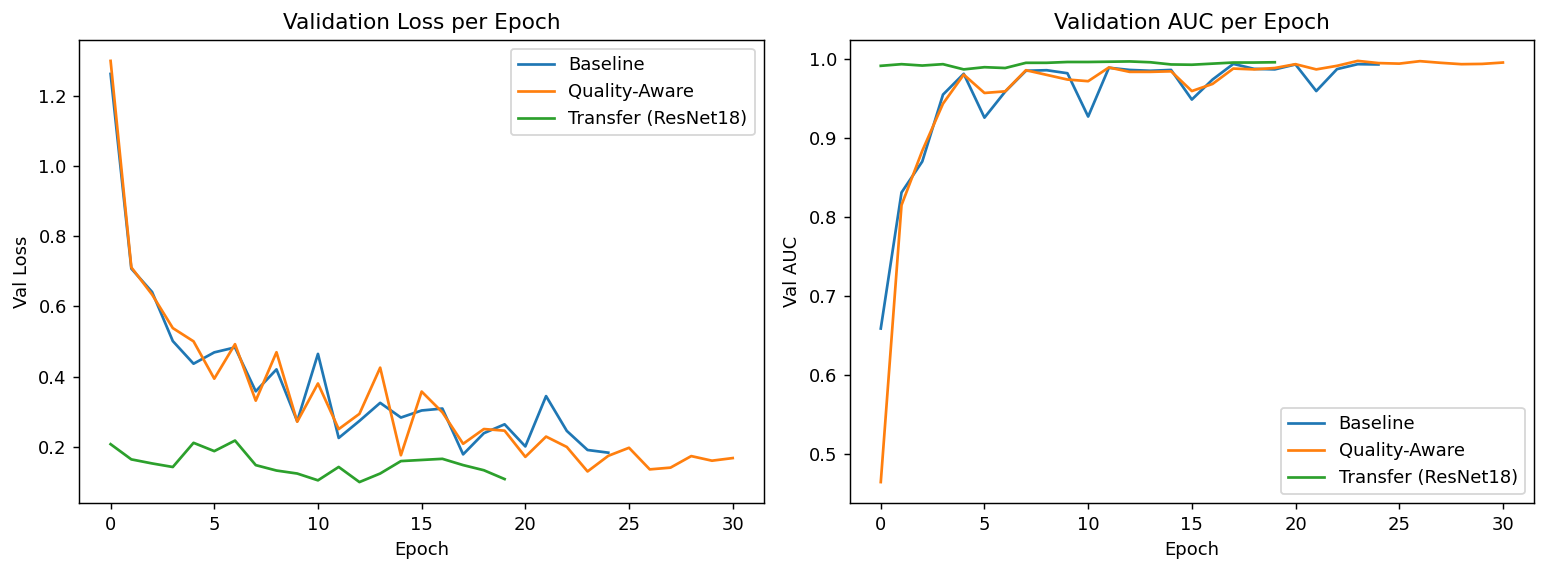

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, hist in [("Baseline", baseline_history), ("Quality-Aware", quality_history), ("Transfer (ResNet18)", transfer_history)]:
    axes[0].plot(hist["val_loss"], label=name)
    axes[1].plot(hist["val_auc"], label=name)
axes[0].set_title("Validation Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Loss"); axes[0].legend()
axes[1].set_title("Validation AUC per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val AUC"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "learning_curves.png"), bbox_inches="tight")
plt.show()

EVALUASI MODEL


Evaluasi: baseline_cnn
{
  "accuracy": 0.9338842975206612,
  "precision": 0.92,
  "recall_sensitivity": 1.0,
  "specificity": 0.7241379310344828,
  "f1_score": 0.9583333333333334,
  "roc_auc": 0.9962518740629684,
  "n_samples": 121
}


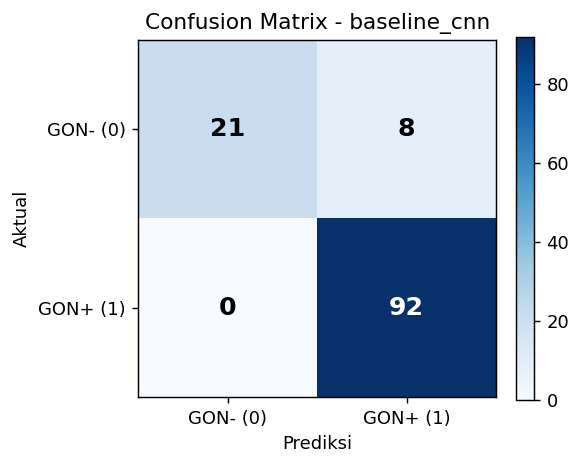


Evaluasi: quality_aware_cnn
{
  "accuracy": 0.9669421487603306,
  "precision": 0.9680851063829787,
  "recall_sensitivity": 0.9891304347826086,
  "specificity": 0.896551724137931,
  "f1_score": 0.978494623655914,
  "roc_auc": 0.9985007496251874,
  "n_samples": 121
}


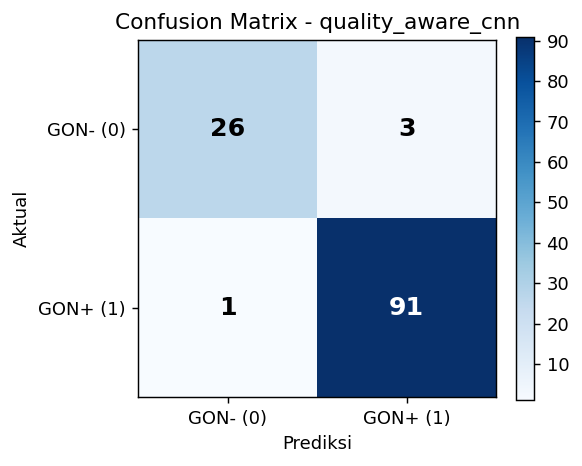


Jumlah False Positive: 3 | Jumlah False Negative: 1
Rata-rata Quality Score FP: 4.72
Rata-rata Quality Score FN: 5.92
Rata-rata Quality Score prediksi BENAR: 5.88


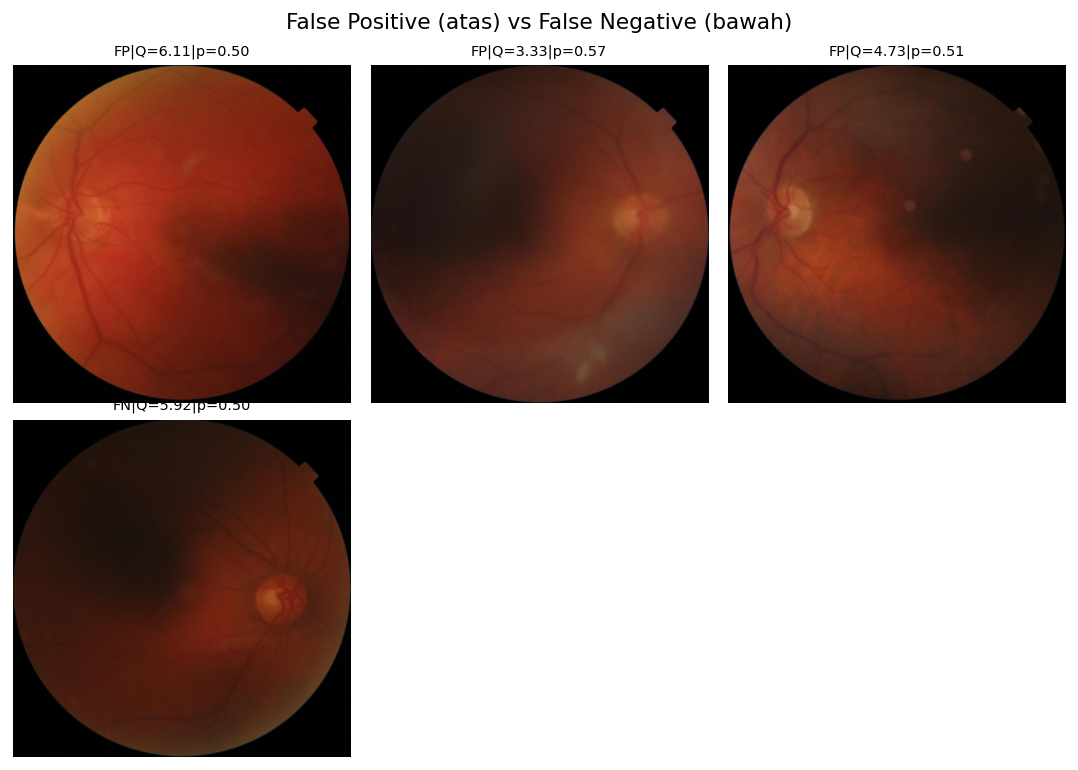


Evaluasi: transfer_resnet18
{
  "accuracy": 0.9834710743801653,
  "precision": 0.9891304347826086,
  "recall_sensitivity": 0.9891304347826086,
  "specificity": 0.9655172413793104,
  "f1_score": 0.9891304347826086,
  "roc_auc": 0.9988755622188905,
  "n_samples": 121
}


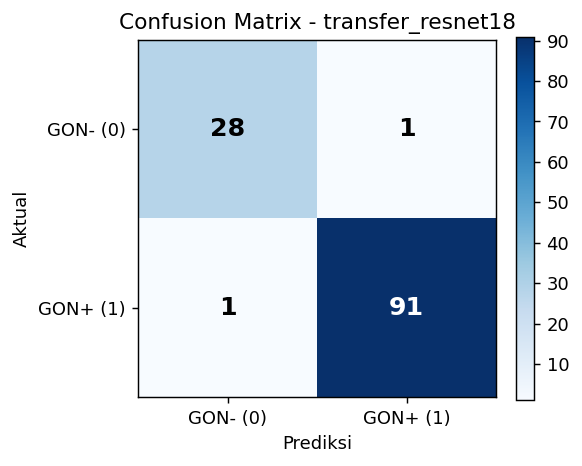

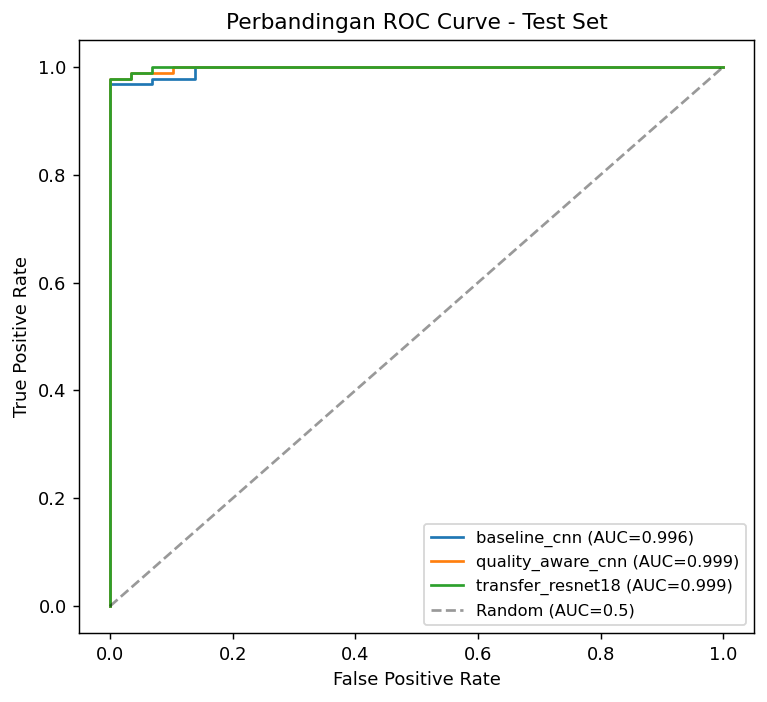


=== Tabel Perbandingan Model ===
            model  accuracy  precision  recall_sensitivity  specificity  f1_score  roc_auc  n_samples
     baseline_cnn  0.933884   0.920000             1.00000     0.724138  0.958333 0.996252        121
quality_aware_cnn  0.966942   0.968085             0.98913     0.896552  0.978495 0.998501        121
transfer_resnet18  0.983471   0.989130             0.98913     0.965517  0.989130 0.998876        121

=== Tabel Stratified Evaluation per Kualitas ===
            model quality_bin  n_samples  accuracy  precision  recall_sensitivity  specificity  f1_score  roc_auc                                 note
     baseline_cnn         low          7  0.714286   0.666667            1.000000     0.333333  0.800000 1.000000                                     
     baseline_cnn      medium         88  0.931818   0.920000            1.000000     0.684211  0.958333 0.996949                                     
     baseline_cnn        high          0       NaN     

In [ ]:
@torch.no_grad()
def get_predictions(model, loader, device=DEVICE, use_quality_input=False):
    model.eval()
    all_labels, all_probs = [], []
    for batch in loader:
        images, labels = batch
        images = images.to(device)
        logits = model(images, None) if use_quality_input else model(images)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.numpy().tolist())
    return np.array(all_labels), np.array(all_probs)


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": auc,
        "confusion_matrix": cm.tolist(),
        "n_samples": len(y_true),
    }


def plot_confusion_matrix(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["GON- (0)", "GON+ (1)"]); ax.set_yticklabels(["GON- (0)", "GON+ (1)"])
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual"); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                     color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=14, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


def stratified_evaluation_by_quality(test_df, y_true, y_prob, model_name):
    """Performa model dipecah per kategori kualitas (low/medium/high) - fokus utama quality-aware analysis."""
    test_df = test_df.reset_index(drop=True).copy()
    test_df["quality_bin"] = test_df["Quality Score"].apply(assign_quality_bin)
    test_df["y_true"] = y_true
    test_df["y_prob"] = y_prob

    rows = []
    for bin_name in ["low", "medium", "high"]:
        subset = test_df[test_df["quality_bin"] == bin_name]
        if len(subset) < 2 or subset["y_true"].nunique() < 2:
            rows.append({"model": model_name, "quality_bin": bin_name, "n_samples": len(subset),
                         "accuracy": np.nan, "precision": np.nan, "recall_sensitivity": np.nan,
                         "specificity": np.nan, "f1_score": np.nan, "roc_auc": np.nan,
                         "note": "Sampel terlalu sedikit/hanya 1 kelas"})
            continue
        m = compute_metrics(subset["y_true"].values, subset["y_prob"].values)
        rows.append({"model": model_name, "quality_bin": bin_name, "n_samples": m["n_samples"],
                     "accuracy": m["accuracy"], "precision": m["precision"],
                     "recall_sensitivity": m["recall_sensitivity"], "specificity": m["specificity"],
                     "f1_score": m["f1_score"], "roc_auc": m["roc_auc"], "note": ""})
    return pd.DataFrame(rows)


def error_analysis(test_df, y_true, y_prob, threshold=0.5, n_examples=5, save_path=None):
    test_df = test_df.reset_index(drop=True).copy()
    y_pred = (y_prob >= threshold).astype(int)
    test_df["y_true"], test_df["y_pred"], test_df["y_prob"] = y_true, y_pred, y_prob

    fp = test_df[(test_df["y_true"]==0) & (test_df["y_pred"]==1)]
    fn = test_df[(test_df["y_true"]==1) & (test_df["y_pred"]==0)]

    print(f"\nJumlah False Positive: {len(fp)} | Jumlah False Negative: {len(fn)}")
    if len(fp): print(f"Rata-rata Quality Score FP: {fp['Quality Score'].mean():.2f}")
    if len(fn): print(f"Rata-rata Quality Score FN: {fn['Quality Score'].mean():.2f}")
    correct = test_df[test_df["y_true"]==test_df["y_pred"]]
    print(f"Rata-rata Quality Score prediksi BENAR: {correct['Quality Score'].mean():.2f}")

    if save_path:
        fp_s = fp.sample(min(n_examples, len(fp)), random_state=42) if len(fp) else fp
        fn_s = fn.sample(min(n_examples, len(fn)), random_state=42) if len(fn) else fn
        n_cols = max(len(fp_s), len(fn_s), 1)
        fig, axes = plt.subplots(2, n_cols, figsize=(n_cols*2.8, 6))
        if n_cols == 1: axes = axes.reshape(2,1)
        for col in range(n_cols):
            if col < len(fp_s):
                r = fp_s.iloc[col]
                img = Image.open(os.path.join(RAW_IMAGE_DIR, r["Image Name"])).convert("RGB")
                axes[0,col].imshow(img)
                axes[0,col].set_title(f"FP|Q={r['Quality Score']}|p={r['y_prob']:.2f}", fontsize=8)
            axes[0,col].axis("off")
            if col < len(fn_s):
                r = fn_s.iloc[col]
                img = Image.open(os.path.join(RAW_IMAGE_DIR, r["Image Name"])).convert("RGB")
                axes[1,col].imshow(img)
                axes[1,col].set_title(f"FN|Q={r['Quality Score']}|p={r['y_prob']:.2f}", fontsize=8)
            axes[1,col].axis("off")
        plt.suptitle("False Positive (atas) vs False Negative (bawah)")
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches="tight")
        plt.show()


# --- Jalankan evaluasi untuk ketiga model ---
test_df_only = split_df[split_df["split"]=="test"].reset_index(drop=True)
_, _, test_ds = build_datasets(split_df, return_quality=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

models_to_eval = [
    (MODEL_BASELINE, baseline_model),
    (MODEL_QUALITY_AWARE, quality_model),
    (MODEL_TRANSFER, transfer_model),
]

metric_rows, stratified_rows, all_results = [], [], {}

for model_name, model in models_to_eval:
    print(f"\n{'='*60}\nEvaluasi: {model_name}\n{'='*60}")
    y_true, y_prob = get_predictions(model, test_loader)
    metrics = compute_metrics(y_true, y_prob)
    print(json.dumps({k:v for k,v in metrics.items() if k!="confusion_matrix"}, indent=2))

    all_results[model_name] = {"y_true": y_true, "y_prob": y_prob, "metrics": metrics}
    metric_rows.append({"model": model_name, **{k:v for k,v in metrics.items() if k!="confusion_matrix"}})

    cm = np.array(metrics["confusion_matrix"])
    plot_confusion_matrix(cm, f"Confusion Matrix - {model_name}",
                          os.path.join(FIGURES_DIR, f"cm_{model_name}.png"))

    strat_df = stratified_evaluation_by_quality(test_df_only, y_true, y_prob, model_name)
    stratified_rows.append(strat_df)

    if model_name == MODEL_QUALITY_AWARE:
        error_analysis(test_df_only, y_true, y_prob,
                       save_path=os.path.join(FIGURES_DIR, "error_analysis.png"))

# --- ROC Curve gabungan ---
fig, ax = plt.subplots(figsize=(6, 5.5))
for model_name, res in all_results.items():
    fpr, tpr, _ = roc_curve(res["y_true"], res["y_prob"])
    ax.plot(fpr, tpr, label=f"{model_name} (AUC={res['metrics']['roc_auc']:.3f})")
ax.plot([0,1],[0,1],"k--", alpha=0.4, label="Random (AUC=0.5)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Perbandingan ROC Curve - Test Set")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "roc_curve_comparison.png"), bbox_inches="tight")
plt.show()

# --- Tabel hasil ---
metrics_table = pd.DataFrame(metric_rows)
metrics_table.to_csv(os.path.join(RESULTS_DIR, "model_comparison_metrics.csv"), index=False)
print("\n=== Tabel Perbandingan Model ===")
print(metrics_table.to_string(index=False))

stratified_table = pd.concat(stratified_rows, ignore_index=True)
stratified_table.to_csv(os.path.join(RESULTS_DIR, "stratified_evaluation_by_quality.csv"), index=False)
print("\n=== Tabel Stratified Evaluation per Kualitas ===")
print(stratified_table.to_string(index=False))

GRAD-CAM

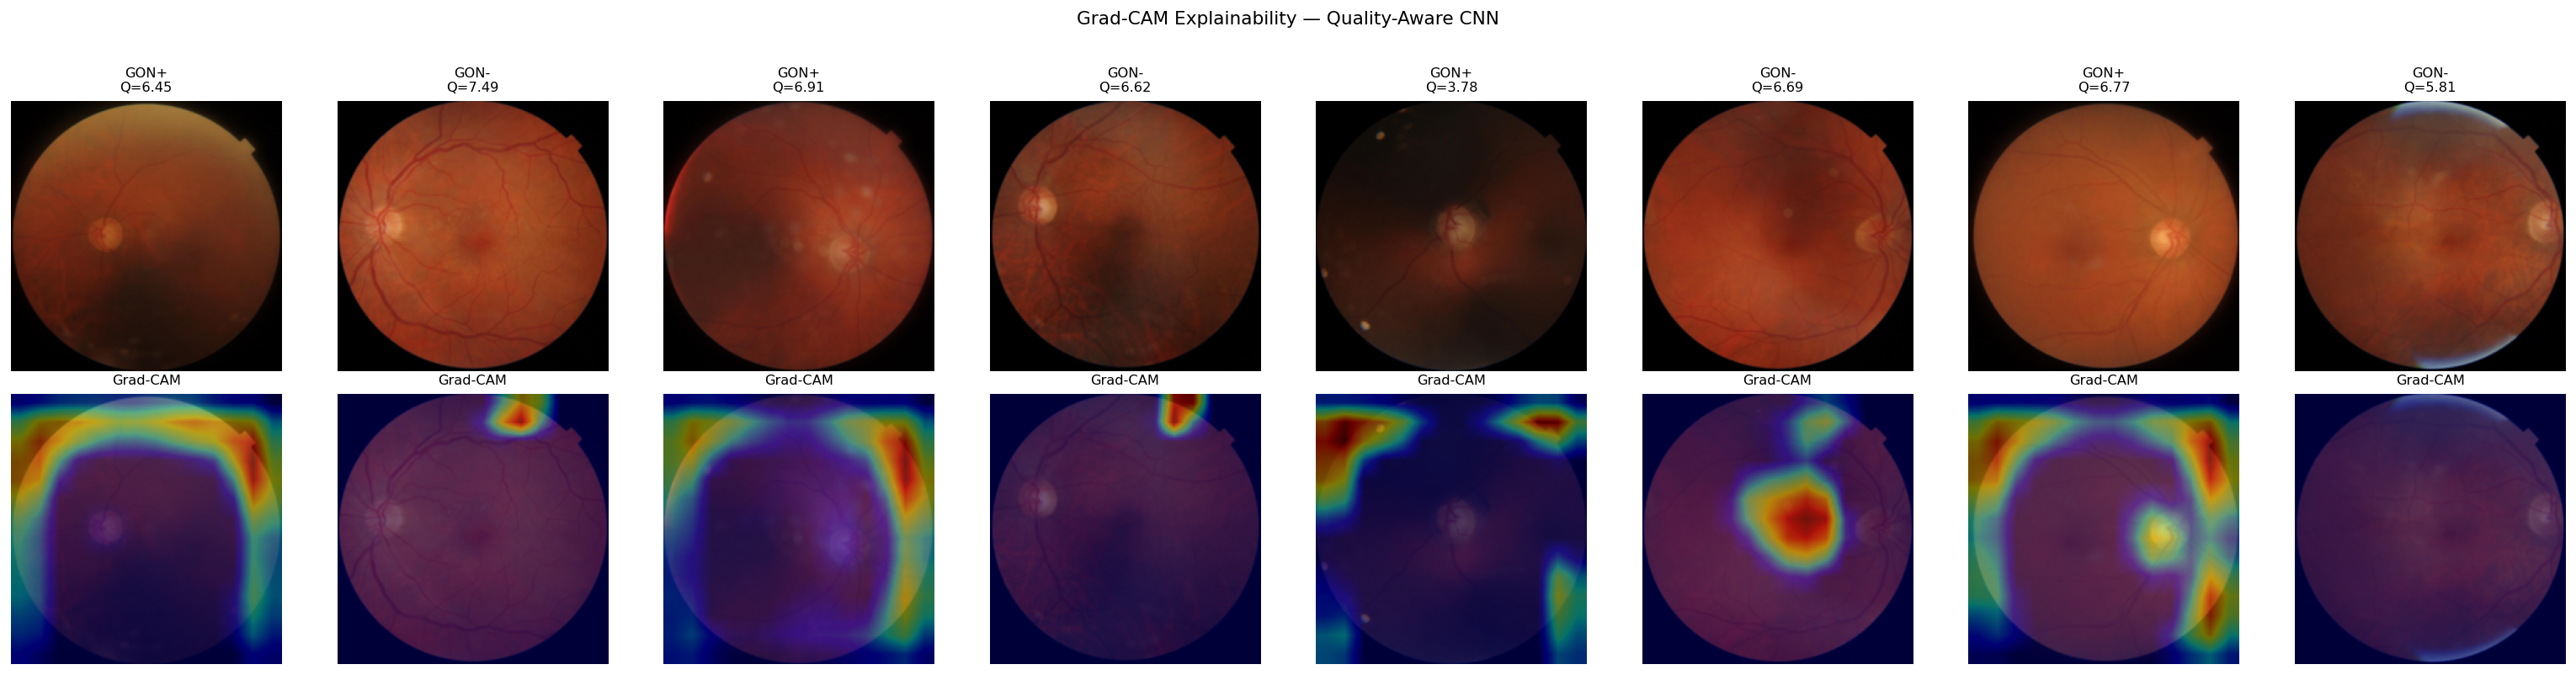

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(DEVICE)
        input_tensor.requires_grad_()
        logit = self.model(input_tensor)
        self.model.zero_grad()
        logit.backward()
        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


def denormalize_image(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std = torch.tensor(IMAGENET_STD).view(3,1,1)
    img = tensor.cpu() * std + mean
    return img.clamp(0,1).permute(1,2,0).numpy()


def visualize_gradcam_all(model, test_df, n_examples=8):
    target_layer = model.features[-1].block[3]
    gradcam = GradCAM(model, target_layer)
    transform = get_eval_transforms()

    # Ambil sampel: campuran GON+ dan GON- secara seimbang
    gon_pos = test_df[test_df["Label"] == "GON+"].sample(
        min(n_examples // 2, len(test_df[test_df["Label"] == "GON+"])), random_state=42)
    gon_neg = test_df[test_df["Label"] == "GON-"].sample(
        min(n_examples // 2, len(test_df[test_df["Label"] == "GON-"])), random_state=42)
    df_sample = pd.concat([gon_pos, gon_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

    n_cols = len(df_sample)
    fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 6))
    if n_cols == 1:
        axes = axes.reshape(2, 1)

    for col, (_, row) in enumerate(df_sample.iterrows()):
        pil_img = Image.open(os.path.join(RAW_IMAGE_DIR, row["Image Name"])).convert("RGB")
        input_tensor = transform(pil_img)
        cam = gradcam.generate(input_tensor)
        original = denormalize_image(input_tensor)

        # Baris atas: gambar asli
        axes[0, col].imshow(original)
        axes[0, col].set_title(f"{row['Label']}\nQ={row['Quality Score']}", fontsize=9)
        axes[0, col].axis("off")

        # Baris bawah: Grad-CAM overlay
        axes[1, col].imshow(original)
        axes[1, col].imshow(cam, cmap="jet", alpha=0.45)
        axes[1, col].set_title("Grad-CAM", fontsize=9)
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Gambar Asli", fontsize=10)
    axes[1, 0].set_ylabel("Grad-CAM Overlay", fontsize=10)

    plt.suptitle("Grad-CAM Explainability — Quality-Aware CNN", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

visualize_gradcam_all(quality_model, test_df_only, n_examples=8)